### 2024 供應鏈風險分數統計摘要
讀取 `1_llm_ready(extract risk paragraph) .ipynb` 產出的 article-level / snippet-level CSV，計算分數分布、零分比例、每篇 snippet 平均數量、matched_bigram 頻率等統計，用來檢查跑批結果是否合理。

> 執行本 notebook 前，請先確認 `1_llm_ready...` 已經跑完 cell 6，產生了下面兩個 2024 年的輸出檔。

In [2]:
import pandas as pd

# 沿用 1_llm_ready(extract risk paragraph) .ipynb 中定義的輸出路徑
year = 2024
article_csv = rf'C:\Users\user\Desktop\ravenpack\RP_SCrisk\2_calculate_supply_chain_risk_and_extract_segments\output\llm_ready_整年\{year}\article_level_scores_{year}_patched.csv'
snippet_csv = rf'C:\Users\user\Desktop\ravenpack\RP_SCrisk\2_calculate_supply_chain_risk_and_extract_segments\output\llm_ready_整年\{year}\llm_ready_data_{year}_context50_snippetlevel_patched.csv'

df_article = pd.read_csv(article_csv)
df_snippet = pd.read_csv(snippet_csv)

print(f"article-level 筆數: {len(df_article)}")
print(f"snippet-level 筆數: {len(df_snippet)}")

C:\Users\user\AppData\Local\Temp\ipykernel_39392\2780599121.py:8: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_article = pd.read_csv(article_csv)


article-level 筆數: 2488287
snippet-level 筆數: 2207756


#### 1. 分數分布 + 零分比例（來源：article-level）

In [3]:
# 分數描述性統計
print("=== sc_risk_score 描述性統計 ===")
print(df_article['sc_risk_score'].describe())

# 分數分桶分布（區間可依實際分數量級調整）
bins = [-0.0001, 0, 0.01, 0.05, 0.1, 0.2, 0.5, float('inf')]
labels = ['0', '(0, 0.01]', '(0.01, 0.05]', '(0.05, 0.1]', '(0.1, 0.2]', '(0.2, 0.5]', '(0.5, +]']
score_bucket = pd.cut(df_article['sc_risk_score'], bins=bins, labels=labels)
bucket_dist = score_bucket.value_counts().sort_index()
bucket_dist_pct = (bucket_dist / len(df_article) * 100).round(2)

print("\n=== sc_risk_score 分桶分布 ===")
print(pd.DataFrame({'文章數': bucket_dist, '佔比(%)': bucket_dist_pct}))

# 零分比例
zero_count = (df_article['sc_risk_score'] == 0).sum()
zero_ratio = zero_count / len(df_article)
print(f"\n=== 零分比例 ===")
print(f"零分文章數: {zero_count} / 總文章數: {len(df_article)} = {zero_ratio:.2%}")

=== sc_risk_score 描述性統計 ===
count    2.488287e+06
mean     1.025281e-02
std      1.351273e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.789846e-03
max      2.311920e+01
Name: sc_risk_score, dtype: float64

=== sc_risk_score 分桶分布 ===
                   文章數  佔比(%)
sc_risk_score                
0              1304982  52.44
(0, 0.01]       930757  37.41
(0.01, 0.05]    201830   8.11
(0.05, 0.1]      23007   0.92
(0.1, 0.2]       10953   0.44
(0.2, 0.5]        6320   0.25
(0.5, +]         10438   0.42

=== 零分比例 ===
零分文章數: 1304982 / 總文章數: 2488287 = 52.44%


#### 2. 每篇 snippet 平均數量（來源：snippet-level + article-level）

In [4]:
snippet_counts = df_snippet.groupby('file_name').size()

print("=== 每篇 snippet 數量描述性統計（僅計有 snippet 的文章）===")
print(snippet_counts.describe())

avg_among_snippet_articles = snippet_counts.mean()
avg_among_all_articles = snippet_counts.sum() / len(df_article)

print(f"\n有 snippet 的文章平均 snippet 數: {avg_among_snippet_articles:.2f}"
      f"（共 {len(snippet_counts)} 篇有 snippet 的文章）")
print(f"全部文章（含零分/無 snippet）平均 snippet 數: {avg_among_all_articles:.2f}"
      f"（共 {len(df_article)} 篇文章）")

=== 每篇 snippet 數量描述性統計（僅計有 snippet 的文章）===
count    582319.000000
mean          3.791317
std           4.600547
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
max         342.000000
dtype: float64

有 snippet 的文章平均 snippet 數: 3.79（共 582319 篇有 snippet 的文章）
全部文章（含零分/無 snippet）平均 snippet 數: 0.89（共 2488287 篇文章）


#### 3. matched_bigram 頻率（來源：snippet-level）

In [5]:
bigram_freq = df_snippet['matched_bigram'].value_counts()

print(f"unique matched_bigram 數量: {bigram_freq.shape[0]}")
print(f"matched_bigram 總出現次數: {bigram_freq.sum()}")
print("\n=== matched_bigram 出現次數前 20 名 ===")
print(bigram_freq.head(20))

unique matched_bigram 數量: 4504
matched_bigram 總出現次數: 2207756

=== matched_bigram 出現次數前 20 名 ===
matched_bigram
and_uncertainties    295836
risk_factors         139518
uncertainties_and     92332
risk_management       49974
may_cause             37969
the_forward           33146
at_risk               31333
and_risk              31092
risk_to               17406
risk_for              17208
risk_in               16604
not_guarantees        14007
act_of                13233
supply_chain          12707
performance_or        12523
the_rating            11449
uncertainty_and       11234
third_party           10331
market_conditions      9906
a_lead                 9670
Name: count, dtype: int64


#### 4. 繪製圖表
用圖表直觀查看分數分布與常見 bigram。

C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:10: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:10: UserWarning: Glyph 31456 (\N{CJK UNIFIED IDEOGRAPH-7AE0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:10: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:10: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:10: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWar

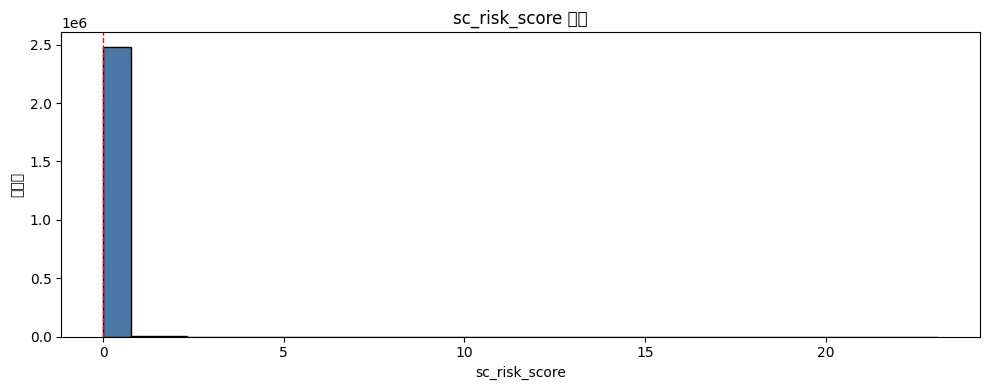

C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:22: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:22: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:22: UserWarning: Glyph 26159 (\N{CJK UNIFIED IDEOGRAPH-662F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:22: UserWarning: Glyph 21542 (\N{CJK UNIFIED IDEOGRAPH-5426}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:22: UserWarning: Glyph 28858 (\N{CJK UNIFIED IDEOGRAPH-70BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:22: UserWarning: Glyph 38646 (\N{CJK 

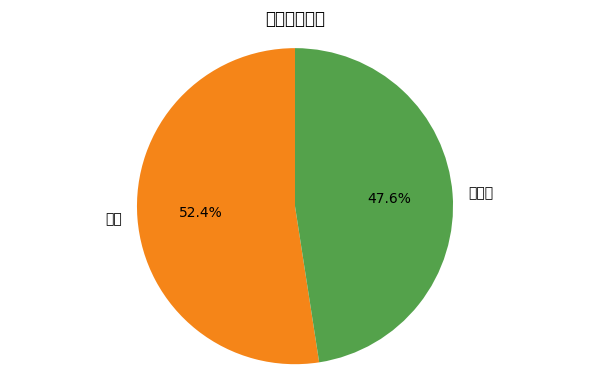

C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:33: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:33: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:33: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:33: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:33: UserWarning: Glyph 38971 (\N{CJK UNIFIED IDEOGRAPH-983B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_39392\3192661123.py:33: UserWarning: Glyph 29575 (\N{CJK 

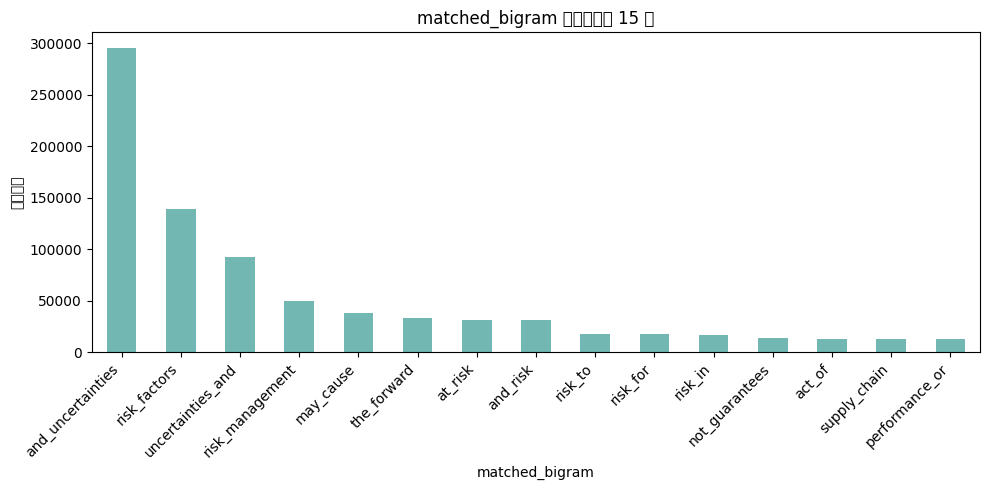

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 讓中文標題與標籤正常顯示
font_candidates = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'KaiTi', 'DengXian', 'DejaVu Sans']
available_fonts = {f.name for f in mpl.font_manager.fontManager.ttflist}
for font in font_candidates:
    if font in available_fonts:
        plt.rcParams['font.sans-serif'] = [font]
        break
else:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 1) sc_risk_score 分布直方圖
plt.figure(figsize=(10, 4))
plt.hist(df_article['sc_risk_score'], bins=30, color='#4C78A8', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.title('sc_risk_score 分布')
plt.xlabel('sc_risk_score')
plt.ylabel('文章數')
plt.tight_layout()
plt.show()

# 2) 零分 / 非零分文章數圓餅圖
zero_mask = df_article['sc_risk_score'] == 0
labels = ['零分', '非零分']
sizes = [zero_mask.sum(), len(df_article) - zero_mask.sum()]

plt.figure(figsize=(6, 4))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#F58518', '#54A24B'])
plt.title('分數是否為零')
plt.axis('equal')
plt.tight_layout()
plt.show()

# 3) matched_bigram 頻率前 15 名長條圖
_top_bigrams = bigram_freq.head(15)
plt.figure(figsize=(10, 5))
_top_bigrams.plot(kind='bar', color='#72B7B2')
plt.title('matched_bigram 出現頻率前 15 名')
plt.xlabel('matched_bigram')
plt.ylabel('出現次數')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 5. 其他輔助欄位（視需要擴充）

In [6]:
print("=== event_type 分布（article-level） ===")
print(df_article['event_type'].value_counts())

print("\n=== total_bigrams 描述性統計（article-level） ===")
print(df_article['total_bigrams'].describe())

=== event_type 分布（article-level） ===
event_type
unknown                             441815
earnings                            150941
product-release                     129449
legal-issues                        127962
stock-price                         125577
                                     ...  
animal-attack                            1
disease-cases                            1
expenses-guidance-expectations           1
initial-coin-offering-regulation         1
economic-union-membership                1
Name: count, Length: 516, dtype: int64

=== total_bigrams 描述性統計（article-level） ===
count    2.488287e+06
mean     1.799991e+03
std      3.081801e+03
min      0.000000e+00
25%      4.620000e+02
50%      8.070000e+02
75%      1.498000e+03
max      4.506300e+04
Name: total_bigrams, dtype: float64
